# 02 - Exploratory Data Analysis (EDA)

## Objective
The purpose of this notebook is to explore the cleaned review-level and product-level master datasets.

This notebook focuses on:
- dataset size and structure
- missing values
- rating and recommendation behavior
- positive bias
- category-level patterns
- skin-type patterns
- product popularity and review density
- basic text and review-length behavior

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)

PROCESSED_DIR = Path("../data/processed")

## 1. Load Processed Master Tables

In [3]:
review_master = pd.read_parquet(PROCESSED_DIR / "review_master.parquet")
product_master = pd.read_parquet(PROCESSED_DIR / "product_master.parquet")

In [4]:
review_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1092743 entries, 0 to 1092742
Data columns (total 43 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   author_id                 1092743 non-null  string        
 1   product_id                1092743 non-null  object        
 2   product_name_final        1092743 non-null  object        
 3   brand_name_final          1092743 non-null  object        
 4   rating                    1092743 non-null  int64         
 5   rating_category           1092743 non-null  object        
 6   is_recommended            924870 non-null   float64       
 7   helpfulness               532274 non-null   float64       
 8   total_feedback_count      1092743 non-null  int64         
 9   total_neg_feedback_count  1092743 non-null  int64         
 10  total_pos_feedback_count  1092743 non-null  int64         
 11  submission_time           1092743 non-null  dateti

In [5]:
product_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8494 entries, 0 to 8493
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_id            8494 non-null   object 
 1   product_name_meta     8494 non-null   object 
 2   brand_id              8494 non-null   int64  
 3   brand_name_meta       8494 non-null   object 
 4   loves_count           8494 non-null   int64  
 5   product_rating        8216 non-null   float64
 6   product_review_count  8216 non-null   float64
 7   size                  6863 non-null   object 
 8   variation_type        7050 non-null   object 
 9   variation_value       6896 non-null   object 
 10  variation_desc        1250 non-null   object 
 11  ingredients           7549 non-null   object 
 12  price_usd_meta        8494 non-null   float64
 13  value_price_usd       451 non-null    float64
 14  sale_price_usd        270 non-null    float64
 15  limited_edition      

## 2. Quick Data Health Check

In [6]:
review_nulls = (
    review_master.isnull()
    .sum()
    .sort_values(ascending=False)
    .to_frame("null_count")
)

review_nulls["null_ratio"] = review_nulls["null_count"] / len(review_master)
review_nulls.head(20)

,null_count,null_ratio
child_min_price,640186,0.585852
child_max_price,640186,0.585852
helpfulness,560469,0.512901
hair_color,226599,0.207367
eye_color,209448,0.191672
skin_tone,170388,0.155927
is_recommended,167873,0.153625
tertiary_category,160969,0.147307
highlights,113703,0.104053
skin_type,111410,0.101954


In [7]:
product_nulls = (
    product_master.isnull()
    .sum()
    .sort_values(ascending=False)
    .to_frame("null_count")
)

product_nulls["null_ratio"] = product_nulls["null_count"] / len(product_master)
product_nulls.head(20)

,null_count,null_ratio
sale_price_usd,8224,0.968213
value_price_usd,8043,0.946904
variation_desc,7244,0.852837
child_min_price,5740,0.675771
child_max_price,5740,0.675771
highlights,2207,0.259830
size,1631,0.192018
variation_value,1598,0.188133
variation_type,1444,0.170002
tertiary_category,990,0.116553


## 3. Core Review-Level Distributions

We first inspect the core target-related variables:
- rating
- recommendation flag
- helper rating category

In [8]:
review_master["rating"].describe()

count    1.092743e+06
mean     4.299071e+00
std      1.149332e+00
min      1.000000e+00
25%      4.000000e+00
50%      5.000000e+00
75%      5.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

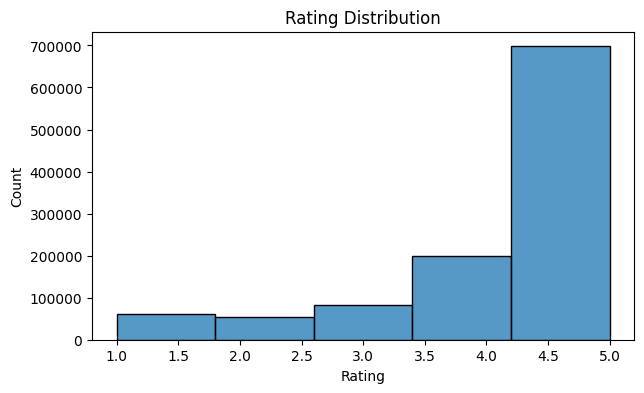

In [9]:
plt.figure(figsize=(7, 4))
sns.histplot(review_master["rating"], bins=5)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

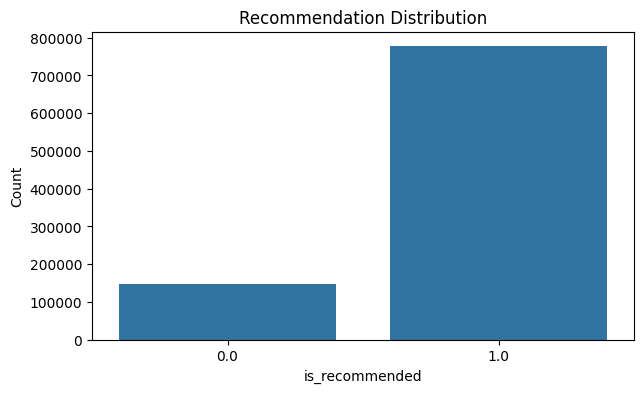

In [10]:
plt.figure(figsize=(7, 4))
sns.countplot(x="is_recommended", data=review_master)
plt.title("Recommendation Distribution")
plt.xlabel("is_recommended")
plt.ylabel("Count")
plt.show()

In [11]:
print("Average rating:", round(review_master["rating"].mean(), 4))

print("\nRating category distribution:")
print(review_master["rating_category"].value_counts(normalize=True).round(4))

print("\nRecommendation ratio:")
print(review_master["is_recommended"].value_counts(normalize=True, dropna=False).round(4))

Average rating: 4.2991

Rating category distribution:
rating_category
positive    0.8208
negative    0.1044
neutral     0.0748
Name: proportion, dtype: float64

Recommendation ratio:
is_recommended
1.0    0.7109
NaN    0.1536
0.0    0.1354
Name: proportion, dtype: float64


## 4. Positive Bias Analysis

This dataset is expected to be positively biased:
- many reviews have high ratings
- many users recommend products

This matters because:
- model performance can look artificially high
- negative signals may be underrepresented
- recommendation quality can be skewed toward already popular/highly-rated products

We inspect this both numerically and visually.

In [12]:
rating_rec_table = (
    review_master.groupby("rating")["is_recommended"]
    .mean()
    .round(4)
    .reset_index()
)

rating_rec_table

,rating,is_recommended
0,1,0.0077
1,2,0.0367
2,3,0.3567
3,4,0.9657
4,5,0.9986


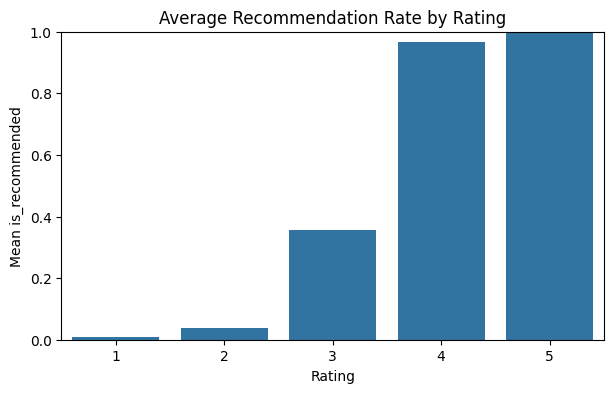

In [13]:
plt.figure(figsize=(7, 4))
sns.barplot(data=rating_rec_table, x="rating", y="is_recommended")
plt.title("Average Recommendation Rate by Rating")
plt.xlabel("Rating")
plt.ylabel("Mean is_recommended")
plt.ylim(0, 1)
plt.show()

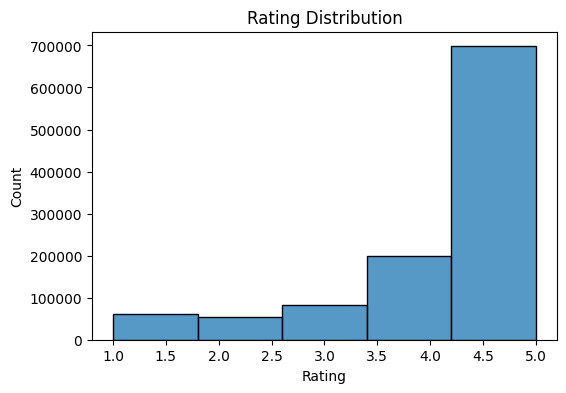

In [43]:
plt.figure(figsize=(6, 4))
sns.histplot(review_master["rating"], bins=5)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

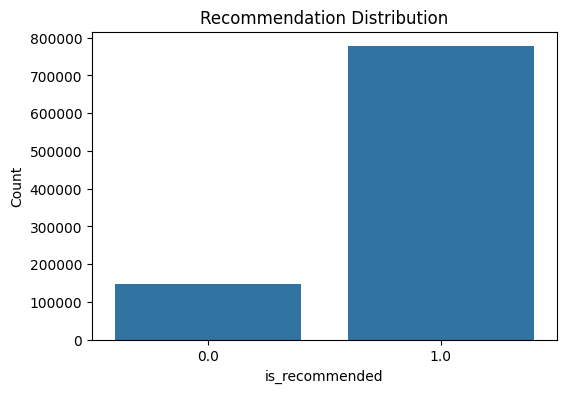

In [44]:
plt.figure(figsize=(6, 4))
sns.countplot(x="is_recommended", data=review_master)
plt.title("Recommendation Distribution")
plt.xlabel("is_recommended")
plt.ylabel("Count")
plt.show()

In [45]:
print("Average rating:", round(review_master["rating"].mean(), 4))

print("\nRating category distribution:")
print(review_master["rating_category"].value_counts(normalize=True).round(4))

print("\nRecommendation ratio:")
print(review_master["is_recommended"].value_counts(normalize=True, dropna=False).round(4))

Average rating: 4.2991

Rating category distribution:
rating_category
positive    0.8208
negative    0.1044
neutral     0.0748
Name: proportion, dtype: float64

Recommendation ratio:
is_recommended
1.0    0.7109
NaN    0.1536
0.0    0.1354
Name: proportion, dtype: float64


### Bias Insight

A high average rating and highly concentrated recommendation behavior indicate a strong positive bias.

This matters because:
- model accuracy can look better than it really is
- minority negative cases may be harder to learn
- ranking can be overly influenced by already popular products

## 5. Review Length and Text Behavior

We inspect text-length patterns because review length may later help:
- estimate review richness
- weight reviews differently
- filter very short/noisy reviews

In [14]:
review_master[["review_text_length", "raw_text_length"]].describe()

,review_text_length,raw_text_length
count,1.092743e+06,1.092743e+06
mean,3.205769e+02,3.347959e+02
std,2.314480e+02,2.353755e+02
min,8.000000e+00,1.600000e+01
25%,1.720000e+02,1.840000e+02
50%,2.630000e+02,2.770000e+02
75%,4.020000e+02,4.190000e+02
max,6.448000e+03,6.461000e+03


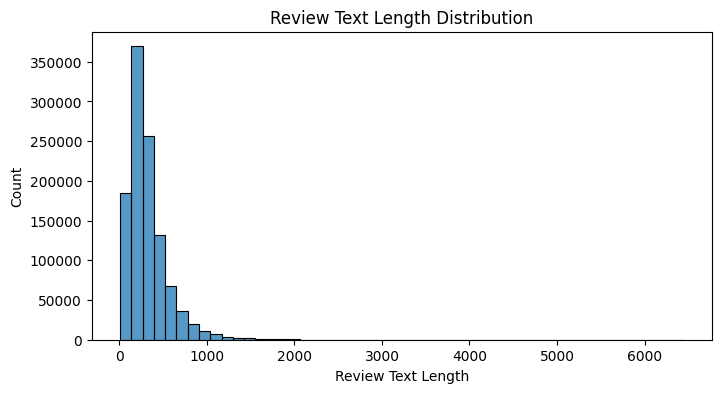

In [15]:
plt.figure(figsize=(8, 4))
sns.histplot(review_master["review_text_length"], bins=50)
plt.title("Review Text Length Distribution")
plt.xlabel("Review Text Length")
plt.ylabel("Count")
plt.show()

In [16]:
review_master.groupby("rating_category")["review_text_length"].mean().round(2)

rating_category
negative    301.40
neutral     340.79
positive    321.17
Name: review_text_length, dtype: float64

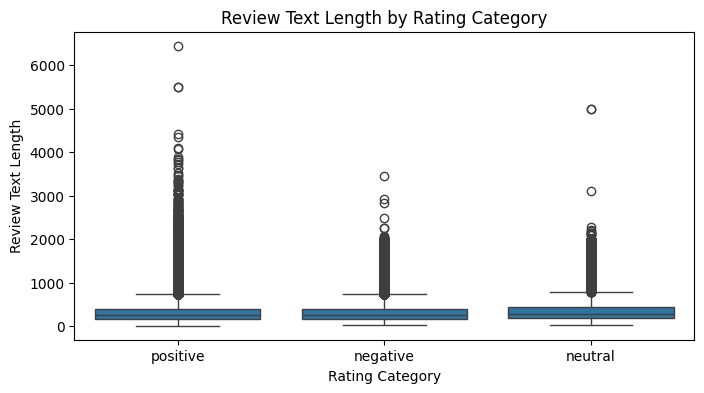

In [17]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=review_master, x="rating_category", y="review_text_length")
plt.title("Review Text Length by Rating Category")
plt.xlabel("Rating Category")
plt.ylabel("Review Text Length")
plt.show()

## 6. Skin-Type Analysis

Skin type is one of the most important fields for the future recommendation logic.
We inspect:
- how common each skin type is
- how rating changes by skin type
- whether recommendation behavior differs across skin types

In [18]:
review_master["skin_type"].value_counts(dropna=False)

skin_type
combination    543712
dry            185651
normal         131674
oily           120296
None           111410
Name: count, dtype: int64

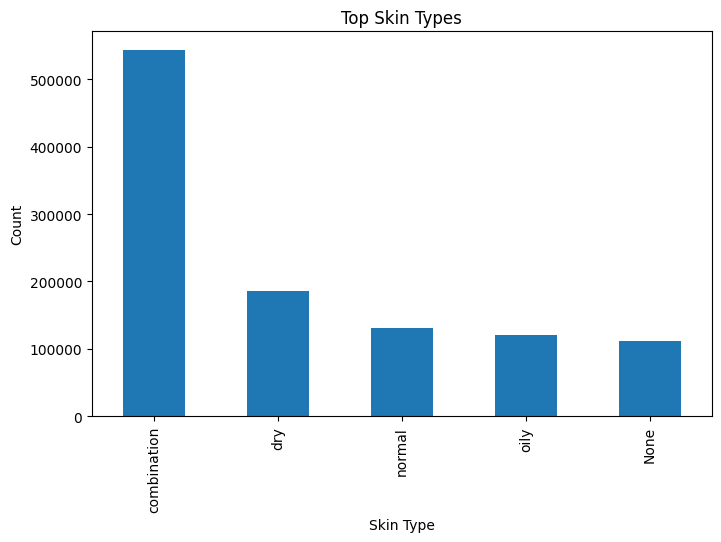

In [19]:
plt.figure(figsize=(8, 5))
review_master["skin_type"].value_counts(dropna=False).head(10).plot(kind="bar")
plt.title("Top Skin Types")
plt.xlabel("Skin Type")
plt.ylabel("Count")
plt.show()

In [20]:
skin_rating = (
    review_master.dropna(subset=["skin_type"])
    .groupby("skin_type")["rating"]
    .agg(["mean", "count"])
    .sort_values("count", ascending=False)
)

skin_rating.head(10)

,mean,count
skin_type,,
combination,4.309449,543712
dry,4.290955,185651
normal,4.282030,131674
oily,4.270898,120296


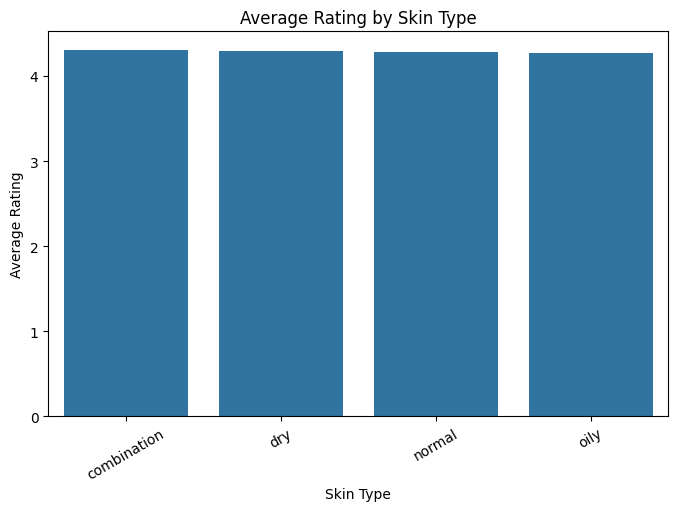

In [21]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=skin_rating.reset_index().head(10),
    x="skin_type",
    y="mean"
)
plt.title("Average Rating by Skin Type")
plt.xlabel("Skin Type")
plt.ylabel("Average Rating")
plt.xticks(rotation=30)
plt.show()

In [22]:
skin_rec = (
    review_master.dropna(subset=["skin_type"])
    .groupby("skin_type")["is_recommended"]
    .mean()
    .sort_values(ascending=False)
)

skin_rec

skin_type
combination    0.844858
dry            0.836223
normal         0.834270
oily           0.833783
Name: is_recommended, dtype: float64

## 7. Category Analysis

Category structure matters because recommendation should later be category-aware.

We inspect:
- review volume by category
- average rating by category
- recommendation rate by category

In [23]:
review_master["primary_category"].value_counts(dropna=False).head(15)

primary_category
Skincare    1092743
Name: count, dtype: int64

## 8. Product Popularity and Review Density

We should not rank products only by average rating.
Products with very few reviews may look artificially strong.

So we inspect:
- most reviewed products
- average rating with review count
- product popularity signals such as loves_count

In [27]:
product_review_summary = (
    review_master.groupby(["product_id", "product_name_final", "brand_name_final"])
    .agg(
        avg_rating=("rating", "mean"),
        review_count=("rating", "count"),
        avg_price=("price_usd_final", "mean"),
        avg_product_rating_meta=("product_rating", "mean"),
        loves_count=("loves_count", "mean")
    )
    .reset_index()
)

In [28]:
product_review_summary.sort_values("review_count", ascending=False).head(10)

,product_id,product_name_final,brand_name_final,avg_rating,review_count,avg_price,avg_product_rating_meta,loves_count
387,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,4.348868,16072,24.0,4.3508,1081315.0
2344,P7880,Soy Hydrating Gentle Face Cleanser,fresh,4.362511,8728,39.0,4.3628,282865.0
42,P218700,100 percent Pure Argan Oil,Josie Maran,4.500129,7760,49.0,4.4998,134089.0
54,P248407,Ultra Repair Cream Intense Hydration,First Aid Beauty,4.518234,7541,38.0,4.5200,300432.0
60,P269122,Alpha Beta Extra Strength Daily Peel Pads,Dr. Dennis Gross Skincare,4.542042,7326,92.0,4.5455,234295.0
199,P394639,The True Cream Aqua Bomb,belif,4.483640,7274,38.0,4.4841,265050.0
359,P417238,Green Clean Makeup Removing Cleansing Balm,Farmacy,4.493892,6139,36.0,4.4958,403801.0
931,P450271,Green Clean Makeup Meltaway Cleansing Balm Limited Edition Jumbo,Farmacy,4.493892,6139,60.0,4.4958,0.0
484,P427421,Protini Polypeptide Firming Refillable Moisturizer,Drunk Elephant,3.960940,6042,68.0,3.9620,411372.0
307,P411387,Superfood Antioxidant Cleanser,Youth To The People,4.210526,5852,39.0,4.2112,404142.0


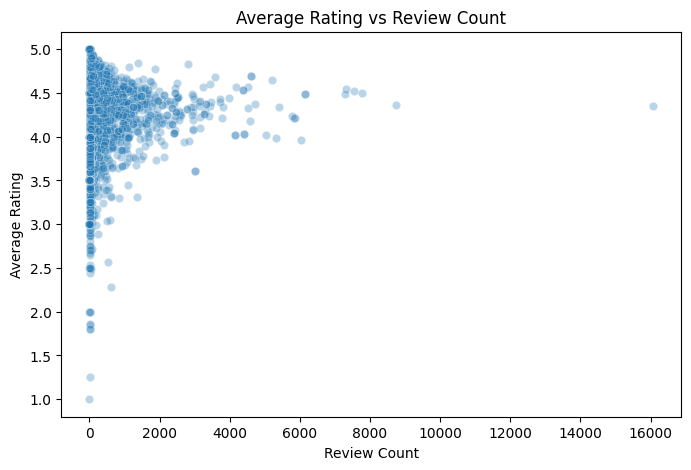

In [29]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=product_review_summary,
    x="review_count",
    y="avg_rating",
    alpha=0.3
)
plt.title("Average Rating vs Review Count")
plt.xlabel("Review Count")
plt.ylabel("Average Rating")
plt.show()

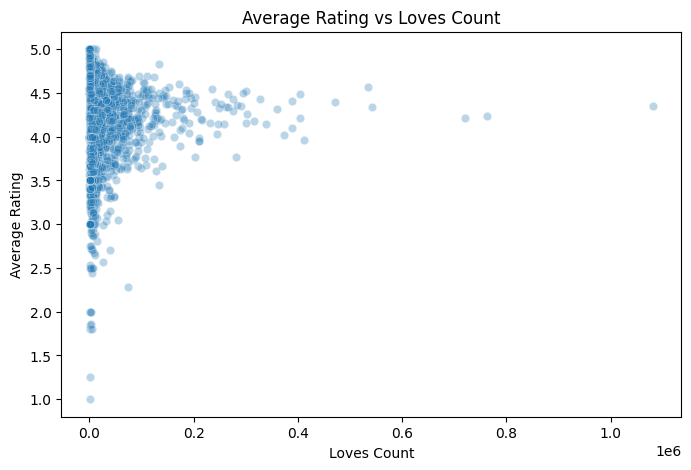

In [30]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=product_review_summary,
    x="loves_count",
    y="avg_rating",
    alpha=0.3
)
plt.title("Average Rating vs Loves Count")
plt.xlabel("Loves Count")
plt.ylabel("Average Rating")
plt.show()

## 9. Minimum-Review Product Ranking Check

A product with 2 reviews and 5.0 average rating should not be treated
the same way as a product with 2,000 reviews and 4.7 average rating.

This section shows how the top-rated product list changes
once we impose a minimum review threshold.

In [31]:
top_products_no_threshold = (
    product_review_summary.sort_values("avg_rating", ascending=False)
    [["product_name_final", "brand_name_final", "avg_rating", "review_count"]]
    .head(10)
)

top_products_no_threshold

,product_name_final,brand_name_final,avg_rating,review_count
1771,The Essence Skincare Boosting Treatment – Lunar New Year Edition,Tatcha,5.0,3
1654,Instant Reset Brightening Overnight Recovery Gel-Cream with Niacinamide Refill,Fenty Skin,5.0,9
2299,Bye Bye Bumps - Best of Body Kit,First Aid Beauty,5.0,1
2298,Vinoperfect Brightening Solution Set,Caudalie,5.0,4
2154,GLOfacial Clarifying Salicylic & Plumping Hyaluronic Acid Concentrate,BeautyBio,5.0,8
2155,GLOfacial Antimicrobial Treatment Tips + Cleaning Brush Accessories,BeautyBio,5.0,7
1775,Smooth + FAB Travel Size Duo,First Aid Beauty,5.0,1
1953,Essential Comfort Balancing Water,Sulwhasoo,5.0,4
1952,Essential Comfort Moisture Cream,Sulwhasoo,5.0,3
1443,Knockout 10% Acid Complex Serum,tarte,5.0,3


In [32]:
min_reviews = 30

top_products_with_threshold = (
    product_review_summary[product_review_summary["review_count"] >= min_reviews]
    .sort_values("avg_rating", ascending=False)
    [["product_name_final", "brand_name_final", "avg_rating", "review_count"]]
    .head(10)
)

top_products_with_threshold

,product_name_final,brand_name_final,avg_rating,review_count
1665,Youth Reformer Firming Vitamin C Oil Serum,FaceGym,4.962264,53
2212,Mini Evening Primrose + Green Tea Algae Retinol Face Oil,MARA,4.948718,78
2217,Evening Primrose + Green Tea Algae Retinol Face Oil,MARA,4.948718,78
380,Tan Build Up Remover Mitt,St. Tropez,4.948276,58
2333,Pore Perfecting Liquid Exfoliator with 2% BHA + Borage,alpyn beauty,4.930000,100
2317,High Performance Face Cleanser for Clear Skin with Niacinamide,MACRENE actives,4.927273,55
2331,Aquarius BHA + Blue Tansy Clarity Cleanser,Herbivore,4.927273,55
2312,High Performance Face Serum with Vitamin C and Hyaluronic Acid,MACRENE actives,4.927083,96
1272,Glow In A Wink ExfoliKate Bestsellers Set,Kate Somerville,4.906667,75
2337,Multi Action Clear Acne Clearing Treatment Lotion for Breakouts,StriVectin,4.903226,31


## 10. Brand-Level Analysis

Brand signals may help later in ranking and product trust estimation.

In [33]:
brand_summary = (
    review_master.groupby("brand_name_final")
    .agg(
        avg_rating=("rating", "mean"),
        review_count=("rating", "count"),
        rec_rate=("is_recommended", "mean")
    )
    .sort_values("review_count", ascending=False)
)

brand_summary.head(15)

,avg_rating,review_count,rec_rate
brand_name_final,,,
CLINIQUE,4.249622,48950,0.834627
Tatcha,4.241020,46685,0.812793
Drunk Elephant,4.085179,42299,0.766801
fresh,4.376433,40820,0.864927
The Ordinary,4.211479,35805,0.819131
Glow Recipe,4.314804,31464,0.837582
Youth To The People,4.281853,29118,0.819730
Origins,4.359804,29038,0.866484
Peter Thomas Roth,4.316003,28813,0.848358


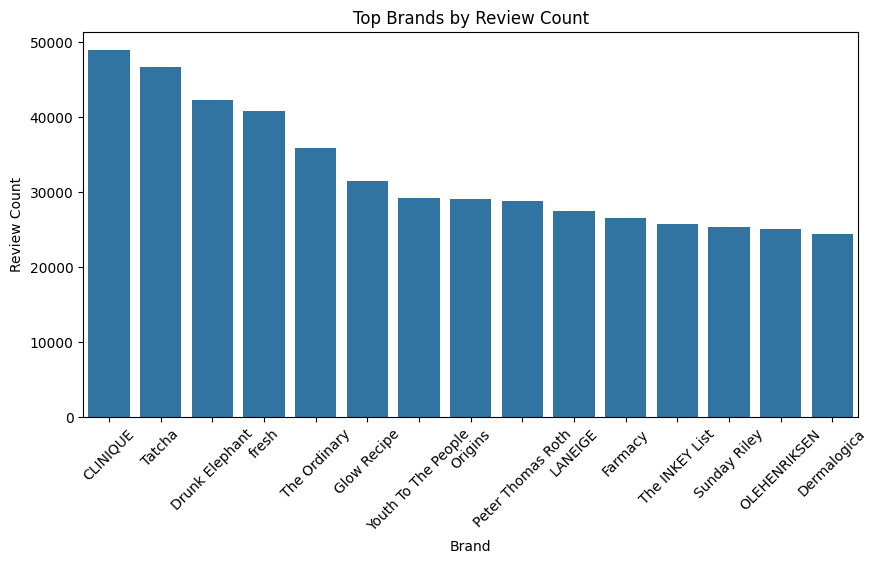

In [34]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=brand_summary.reset_index().head(15),
    x="brand_name_final",
    y="review_count"
)
plt.title("Top Brands by Review Count")
plt.xlabel("Brand")
plt.ylabel("Review Count")
plt.xticks(rotation=45)
plt.show()

## 11. Price Analysis

Price can be used later as:
- a filtering signal
- a ranking feature
- a budget segmentation feature

In [35]:
review_master["price_usd_final"].describe()

count    1.092743e+06
mean     4.901882e+01
std      4.005620e+01
min      3.000000e+00
25%      2.500000e+01
50%      3.900000e+01
75%      6.200000e+01
max      1.900000e+03
Name: price_usd_final, dtype: float64

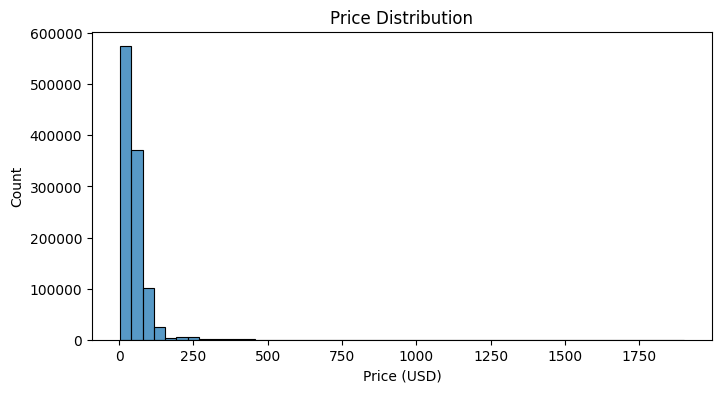

In [36]:
plt.figure(figsize=(8, 4))
sns.histplot(review_master["price_usd_final"].dropna(), bins=50)
plt.title("Price Distribution")
plt.xlabel("Price (USD)")
plt.ylabel("Count")
plt.show()

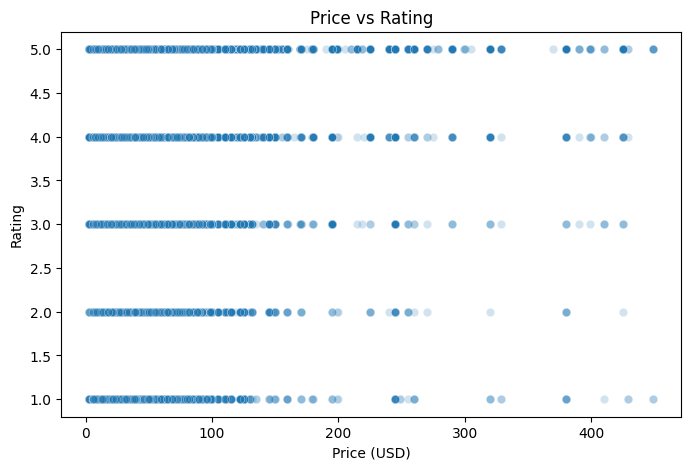

In [37]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=review_master.sample(min(50000, len(review_master)), random_state=42),
    x="price_usd_final",
    y="rating",
    alpha=0.2
)
plt.title("Price vs Rating")
plt.xlabel("Price (USD)")
plt.ylabel("Rating")
plt.show()

## 12. Skin Type × Category Cross-Analysis

This section is especially useful for future concern-aware recommendation logic.

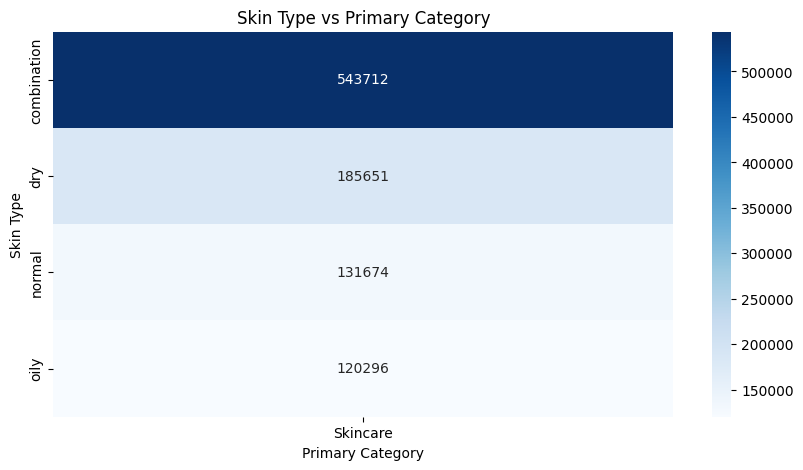

In [39]:
top_skin_types = review_master["skin_type"].value_counts().head(5).index
top_categories = review_master["primary_category"].value_counts().head(8).index

filtered_cross = pd.crosstab(
    review_master.loc[review_master["skin_type"].isin(top_skin_types), "skin_type"],
    review_master.loc[review_master["primary_category"].isin(top_categories), "primary_category"]
)

plt.figure(figsize=(10, 5))
sns.heatmap(filtered_cross, annot=True, fmt="d", cmap="Blues")
plt.title("Skin Type vs Primary Category")
plt.xlabel("Primary Category")
plt.ylabel("Skin Type")
plt.show()

## 13. Numeric Correlation Overview

This is only a high-level view and should not be over-interpreted.

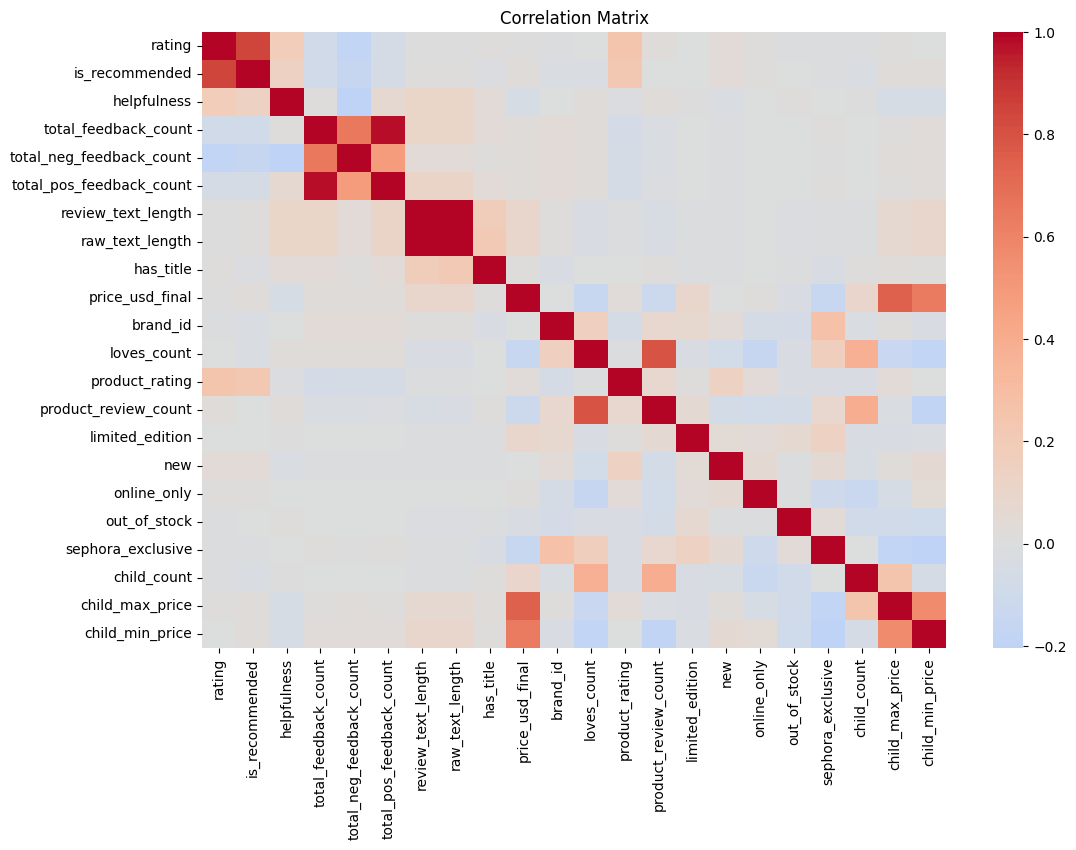

In [40]:
num_cols = review_master.select_dtypes(include=["int64", "float64", "Int64"]).copy()
corr = num_cols.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

## 14. Key EDA Takeaways

In [41]:
print("Top 10 primary categories by review count:")
print(review_master["primary_category"].value_counts().head(10))

print("\nTop 10 skin types:")
print(review_master["skin_type"].value_counts(dropna=False).head(10))

print("\nAverage rating:", round(review_master["rating"].mean(), 4))

print("\nRecommendation ratio:")
print(review_master["is_recommended"].value_counts(normalize=True, dropna=False).round(4))

Top 10 primary categories by review count:
primary_category
Skincare    1092743
Name: count, dtype: int64

Top 10 skin types:
skin_type
combination    543712
dry            185651
normal         131674
oily           120296
None           111410
Name: count, dtype: int64

Average rating: 4.2991

Recommendation ratio:
is_recommended
1.0    0.7109
NaN    0.1536
0.0    0.1354
Name: proportion, dtype: float64


# Conclusion

This EDA shows that:

- the dataset is strongly positively biased
- some categories dominate the review volume
- skin type is an important and non-trivial feature
- review density varies a lot by product
- product quality should not be inferred from average rating alone
- price and popularity signals may be useful in downstream ranking

## Next Step
The next notebook should focus on:
- concern dictionary design
- text preprocessing
- typo/variant-aware matching
- review-to-concern mapping